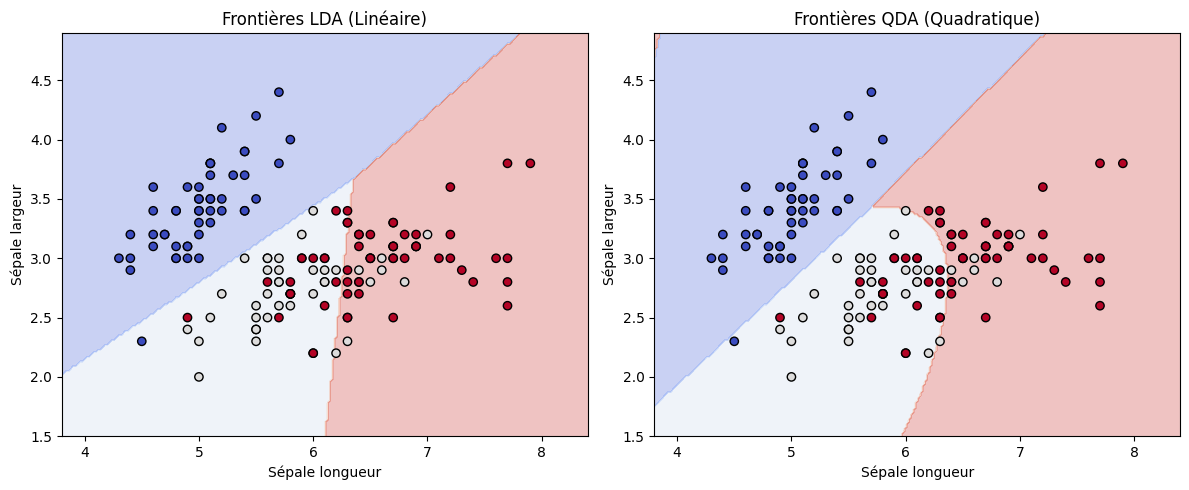

In [1]:
# --- 1. Importation des bibliothèques ---
import matplotlib.pyplot as plt
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.datasets import load_iris

# --- 2. Chargement et préparation des données ---
iris = load_iris()
X = iris.data[:, :2]  # On prend uniquement les 2 premières caractéristiques pour la visualisation
y = iris.target

# --- 3. Entraînement des modèles LDA et QDA ---
lda = LinearDiscriminantAnalysis()
qda = QuadraticDiscriminantAnalysis()

lda.fit(X, y)
qda.fit(X, y)

# --- 4. Fonction pour la visualisation des frontières ---
def plot_boundaries(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.coolwarm)
    plt.title(title)
    plt.xlabel('Sépale longueur')
    plt.ylabel('Sépale largeur')

# --- 5. Affichage des résultats ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plot_boundaries(lda, X, y, "Frontières LDA (Linéaire)")

plt.subplot(1, 2, 2)
plot_boundaries(qda, X, y, "Frontières QDA (Quadratique)")

plt.tight_layout()
plt.show()